This notebook is a localization problem. Where I simulate the performance of a single contrast localizer of different thresholds compared to  multitask localizers

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
import OptimalBattery.estimate as et
import matplotlib.cm as cm



In [2]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

# start with some U_true, in this simulation its 5 parcels

In [3]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [4]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [5]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

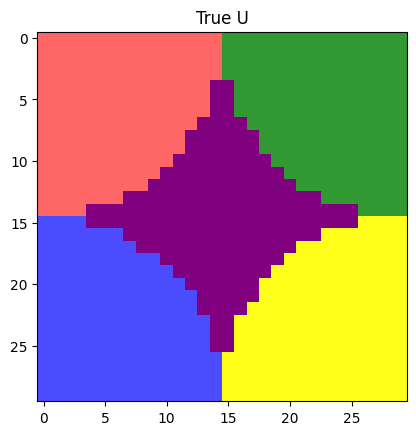

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5,device=device, dtype=pt.float64)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5.cpu().numpy(), title = 'True U')

for the evaluations we will need to compare resulting Uhats to a Utrue and the U true needs to be collapsed into only the parcel of interest (parcel 5 and everything else)

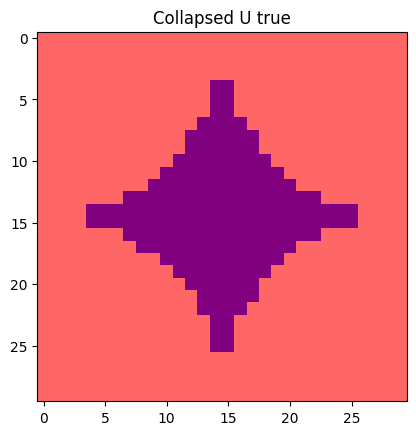

In [7]:
everything_else = U_true_5[ :4, :].sum(dim=0, keepdim=True)
parcel_of_interest = U_true_5[ 4:, :]
collapsed_U_true = pt.cat([everything_else, parcel_of_interest], dim=0).to(device)  

plot_Us(collapsed_U_true.cpu().numpy(), title='Collapsed U true')

# Run the analysis 

In [8]:
battery_sizes = [3,4,5,6,7,8,12,16,20,24]
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
num_task_lib = 100
n_parcels = 5
base_noise = 10

n_iter = 5
n_batteries = 1000

In [9]:
iteration_df_multi = pd.DataFrame()
for i in range(n_iter):
    print(f'Iteration{i}')
    results_df = sim.sim_parcellation(num_task_lib = num_task_lib,
                     n_parcels = n_parcels,
                     U_true = U_true_5,
                     battery_sizes = battery_sizes,
                     n_batteries = n_batteries,
                     base_noise = base_noise,
                     collapsed_U_true=collapsed_U_true,
                     seed = None)
    results_df['iteration'] = i
    iteration_df_multi = pd.concat([iteration_df_multi,results_df],axis=0)

Iteration0
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Processing battery size: 24
Iteration1
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Processing battery size: 24
Iteration2
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Processing battery size: 24
Iteration3
Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7

In [10]:
# only using top batteries for log_det_mc
filtered_multi = iteration_df_multi[iteration_df_multi['metric'] == 'log_det_mc']
# Group and summarize
summary_multi = filtered_multi.groupby('n_task')['accuracy'].agg(
    mean_accuracy='mean',
    sem_accuracy=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

# single dimensional localizer

In [11]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95,0.99]

In [ ]:
iteration_df_single = pd.DataFrame()
for i in range(n_iter):
    print(f'Iteration{i}')
    results_df = sim.sim_single_contrast(num_task_lib = num_task_lib,
                            n_parcels = n_parcels,
                            U_true = U_true_5,
                            base_noise = base_noise,
                            max_battery_size = max(battery_sizes),
                            thresholds = thresholds,
                            U_true_collapsed = collapsed_U_true,
                            seed = None)
    results_df['iteration'] = i
    iteration_df_single = pd.concat([iteration_df_single,results_df],axis=0)


Iteration0
Iteration1
Iteration2
Iteration3
Iteration4
Iteration5
Iteration6
Iteration7
Iteration8
Iteration9
Iteration10
Iteration11
Iteration12
Iteration13
Iteration14
Iteration15
Iteration16
Iteration17
Iteration18
Iteration19
Iteration20
Iteration21
Iteration22
Iteration23
Iteration24
Iteration25
Iteration26
Iteration27
Iteration28
Iteration29
Iteration30
Iteration31
Iteration32
Iteration33
Iteration34
Iteration35
Iteration36
Iteration37
Iteration38
Iteration39
Iteration40
Iteration41
Iteration42
Iteration43
Iteration44
Iteration45
Iteration46
Iteration47
Iteration48
Iteration49
Iteration50
Iteration51
Iteration52
Iteration53
Iteration54
Iteration55
Iteration56
Iteration57
Iteration58
Iteration59
Iteration60
Iteration61
Iteration62
Iteration63
Iteration64
Iteration65
Iteration66
Iteration67
Iteration68
Iteration69
Iteration70
Iteration71
Iteration72
Iteration73
Iteration74
Iteration75
Iteration76
Iteration77
Iteration78
Iteration79
Iteration80
Iteration81
Iteration82
Iteration83
It

In [16]:
summary_df = iteration_df_single.groupby(['threshold'])['accuracy'].agg(
    mean_accuracy='mean',
    sem_accuracy=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()


# compare

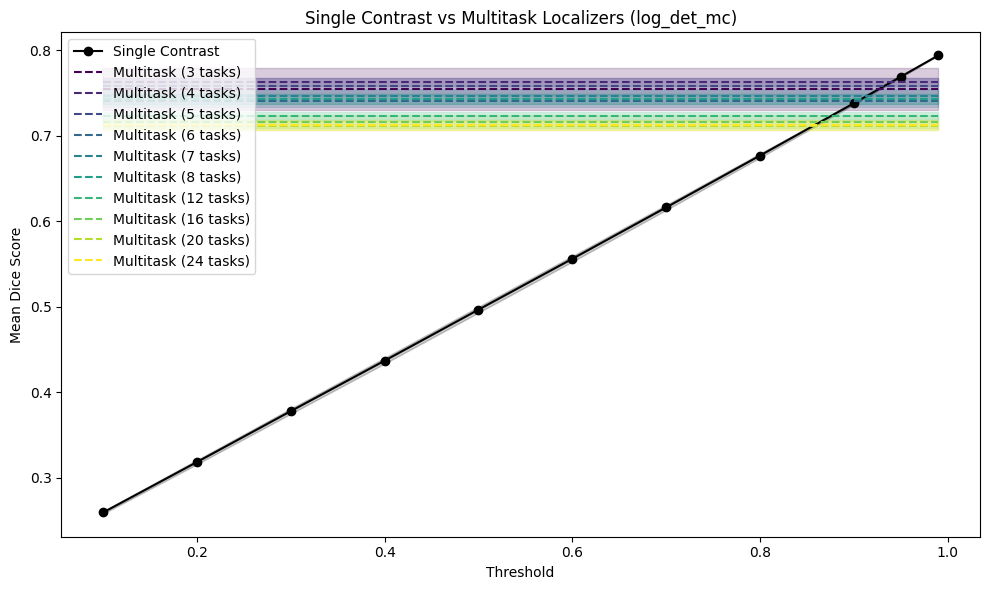

In [17]:
plt.figure(figsize=(10, 6))

# plit single first
x = summary_df['threshold']
y = summary_df['mean_accuracy']
sem = summary_df['sem_accuracy']

plt.plot(x, y, label='Single Contrast', marker='o', color='black')
plt.fill_between(x, y - sem, y + sem, alpha=0.2, color='black')


# plot multi
colors = cm.viridis(np.linspace(0, 1, len(summary_multi)))
xmin, xmax = x.min(), x.max()
for i, row in summary_multi.iterrows():
    mean = row['mean_accuracy']
    sem = row['sem_accuracy']
    n_task = int(row['n_task'])

    # lines
    plt.hlines(mean, xmin=xmin, xmax=xmax,
               colors=colors[i], linestyles='dashed', label=f'Multitask ({n_task} tasks)')

    # sem
    plt.fill_between([xmin, xmax],
                     [mean - sem]*2,
                     [mean + sem]*2,
                     color=colors[i],
                     alpha=0.2)

# Labels, legend, etc.
plt.xlabel('Threshold')
plt.ylabel('Mean Dice Score')
plt.title('Single Contrast vs Multitask Localizers (log_det_mc)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
